In [1]:
import pandas as pd # For DataFrame manipulation
import numpy as np # For numerical operations
import matplotlib.pyplot as plt # For basic plotting
import seaborn as sns # For advanced statistical plotting

In [2]:
# 2. Configuration
# Set the visual style to 'whitegrid' (clean look with grid)
sns.set_theme(style="whitegrid")

# Ensure plots are shown inside the notebook
%matplotlib inline

# Suppress warnings to keep the output clean
import warnings
warnings.filterwarnings('ignore')

print("Setup Complete. Libraries Loaded.")

Setup Complete. Libraries Loaded.


In [3]:
df=sns.load_dataset('titanic')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [9]:

print("-" * 30)
print("Data Info (Types and Missing Values):")
df.info()

------------------------------
Data Info (Types and Missing Values):
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [10]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: xlabel='age', ylabel='fare'>

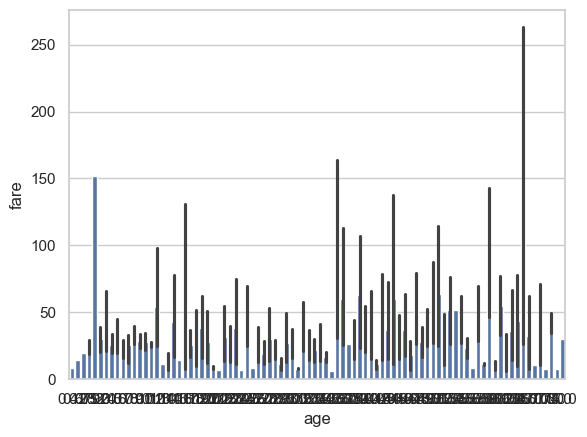

In [16]:
sns.barplot(data=df,x='age',y='fare')


In [22]:
missing=df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct


survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [20]:
len(df)

891

In [24]:
missing_df = pd.DataFrame({'Missing': missing, 'Pct': missing_pct})
missing_df

,Missing,Pct
survived,0,0.000000
pclass,0,0.000000
sex,0,0.000000
age,177,19.865320
sibsp,0,0.000000
parch,0,0.000000
fare,0,0.000000
embarked,2,0.224467
class,0,0.000000
who,0,0.000000


In [30]:
missing_df[missing_df['Missing']>0].sort_values('Missing',ascending=False)

,Missing,Pct
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467


In [31]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df['deck'].value_counts(dropna=Fa)

deck
C    59
B    47
D    33
E    32
A    15
F    13
G     4
Name: count, dtype: int64

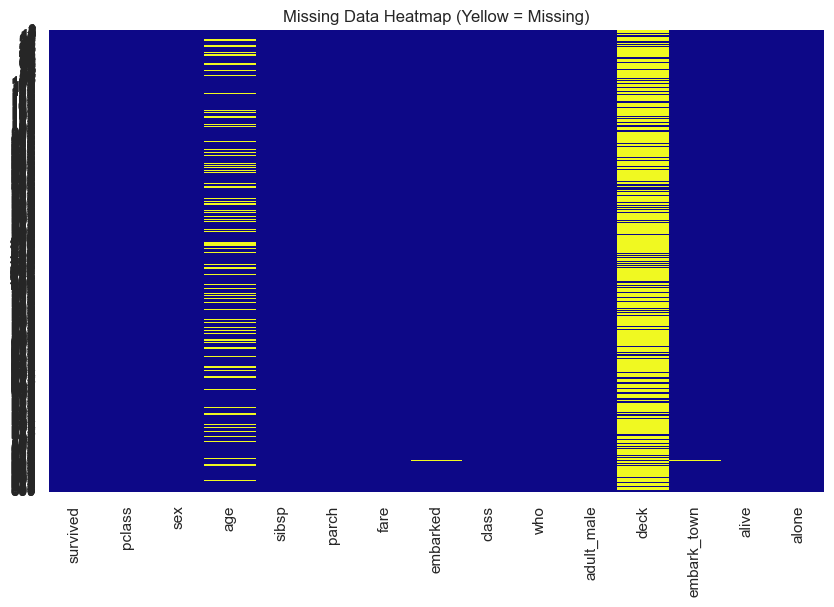

In [44]:
# Visualizing Missing Data using a Heatmap

plt.figure(figsize=(10, 6))

# sns.heatmap logic:
# df.isnull() returns a DataFrame of True/False (True if missing)
# cbar=False: Hide the color bar legend
# yticklabels=False: Hide row numbers (too messy for big data)
# cmap='viridis': Yellow = True (Missing), Purple = False (Present)
sns.heatmap(df.isnull(), cbar=False,cmap='plasma', yticklabels=True)

plt.title('Missing Data Heatmap (Yellow = Missing)')
plt.show()

In [61]:
df['age']= df['age'].fillna(df['age'].median())

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [72]:
df['embarked']=df['embarked'].fillna(df['embarked'].mode()[0])

In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [71]:
df['embarked'].mode()[0]

'S'

In [74]:
df= df.drop('deck',axis=1)

In [75]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,28.0,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  embark_town  889 non-null    str     
 12  alive        891 non-null    str     
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(5)
memory usage: 79.4 KB


<Axes: xlabel='survived', ylabel='count'>

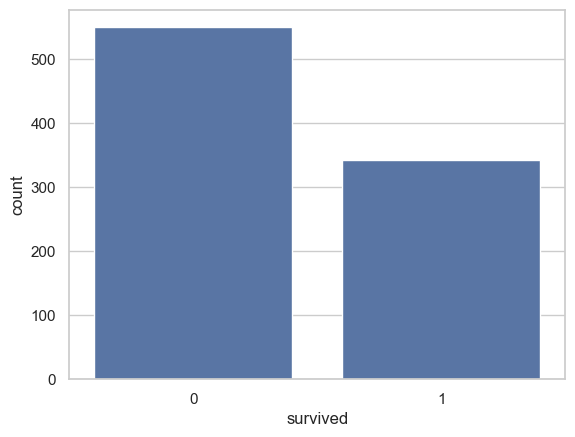

In [77]:
sns.countplot(data=df,x='survived')

<Axes: xlabel='fare', ylabel='Count'>

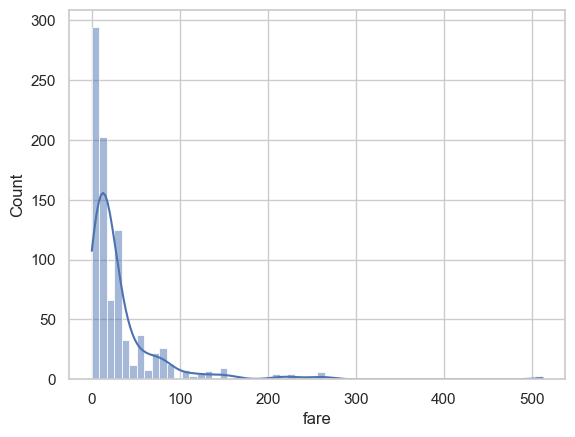

In [81]:
sns.histplot(data=df,kde=True,x='fare')

In [ ]:
sns.kdeplot(data=df,x='age')


In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  embark_town  889 non-null    str     
 12  alive        891 non-null    str     
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(5)
memory usage: 79.4 KB


In [87]:
num_cols= ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
df_corr=df[num_cols].corr()
df_corr

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
sibsp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


<Axes: >

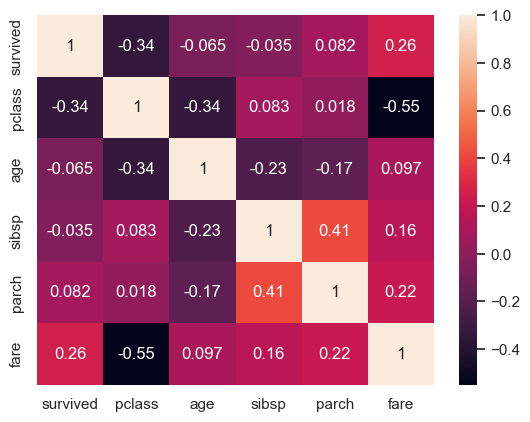

In [89]:
sns.heatmap(df_corr,annot=True)

In [90]:
df['fare'].skew()

np.float64(4.787316519674893)

In [91]:
df['age'].skew()

np.float64(0.5102446555756495)

<Axes: xlabel='sex', ylabel='survived'>

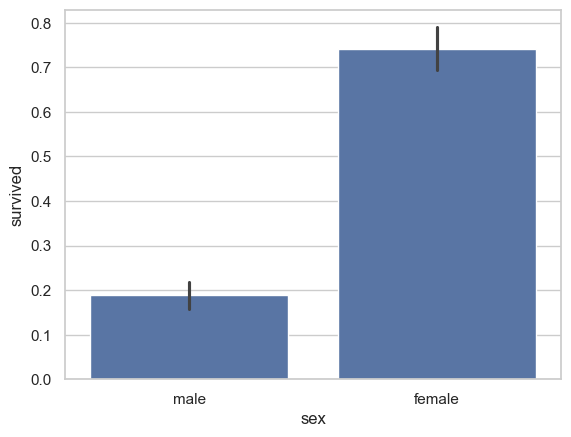

In [92]:
sns.barplot(data=df,x='sex',y='survived')

<Axes: xlabel='age', ylabel='Density'>

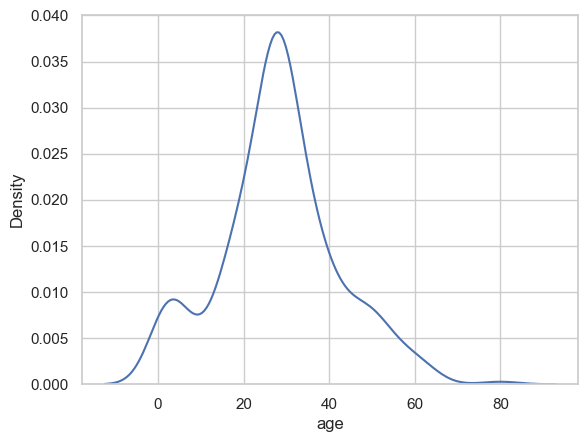

In [94]:
sns.kdeplot(data=df[df['survived']==1],x=  'age')

In [97]:
pd.crosstab([df['sex'],df['pclass']],df['survived'], normalize='index')

survived              0         1
sex    pclass                    
female 1       0.031915  0.968085
       2       0.078947  0.921053
       3       0.500000  0.500000
male   1       0.631148  0.368852
       2       0.842593  0.157407
       3       0.864553  0.135447

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn datasets and tools
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [1]:
!pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)

   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   -------------------- ------------------- 1/2 [scikit-


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
